## Local deploying and serving 
Servir et interroger des modèles localement est très simple et peut être effectué en ligne de commande. Si vous souhaitez simplement servir le dernier modèle, vous pouvez le faire en utilisant l'ID du run .

Avant de commencer, accédez à nouveau à l'interface utilisateur de MLFlow et cliquez sur l'expérience scikit_learn_experiment. Choisissez une exécution et copiez l'ID de l'exécution. N'oubliez pas non plus le nom du modèle avec lequel vous avez enregistré le modèle, qui devrait être log_reg_model. 


In [1]:
import pandas as pd
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score,confusion_matrix
import numpy as np
import subprocess
import json

Tout d'abord, vous devez remplacer votre répertoire par un répertoire contenant le dossier mlruns avec toutes vos expériences. Ensuite, vous avez besoin de deux choses : l'ID du run de votre modèle et le nom de votre modèle. 

Une fois vous aurez ces information, exécutez cette commande:

> mlflow models serve --model-uri runs:/YOUR_MODEL_RUN/YOUR_MODEL_NAME -p 1235

MLFlow devrait commencer à construire immédiatement un nouvel environnement conda qu'il utilisera pour servir localement. Dans cet environnement, il installe des packages de base et des packages spécifiques que le modèle doit pouvoir s'exécuter.

notre modèle est servi sur : http://localhost:1235/ 

### Interroger le modèle 

Vous êtes maintenant prêt à interroger le modèle avec des données et à recevoir des prédictions. C'est là qu'intervient le module subprocess (ou requests). Tout d'abord, chargeons à nouveau notre dataframe. Exécutez le code suivant : 

#### Interrogation en utilisant subprocess

In [4]:
df = pd.read_csv("data/creditcard.csv")

In [5]:
input_json = df.iloc[:80].drop(["Time", "Class"],axis=1).to_json(orient="split")

# nous allons extraire 80 valeur pour interroger mle modèle avec 

In [6]:
proc = subprocess.run(["curl", "-X", "POST", "-H","Content-Type:application/json; format=pandas-split",
"--data", input_json, "http://127.0.0.1:1235/invocations"],
stdout=subprocess.PIPE, encoding='utf-8')

In [7]:
output = proc.stdout
df2 = pd.DataFrame([json.loads(output)])
df2

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


#### Interrogation en utilisant requests 

In [10]:
import requests 

In [27]:
import requests

host = '127.0.0.1'
port = '1235'

url = f'http://{host}:{port}/invocations'

headers = {
    'Content-Type': 'application/json',
}
r = requests.post(url=url, headers=headers, data=input_json)

print(f'Predictions: {r.text}')

Predictions: [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


ce que nous avons fait en haut (subprocess ou request) est équivalent à exécuter la commande ci-dessous sur l'invité de commande:

> curl -X POST -H "Content-Type:application/json;
format=pandas-split"
–data "CONTENT_OF_INPUT_JSON"
"http://127.0.0.1:1235/invocations"

Le cœur du problème est que si vous exécutez cela en ligne de commande, coller les données au format JSON peut devenir très compliqué car il y a tellement de colonnes. C'est pourquoi nous avons choisi d'utiliser subprocess ou requests car il est plus facile de transmettre directement le JSON lui-même en utilisant un nom de variable, input_json dans ce cas, pour contenir le contenu du JSON. 

#### Batch querying 

Malheureusement, il y a un maximum d'enregistrements qu'on peut envoyer pour la prédiction (presque 80).

Afin de remédier à ce problème, nous pouvons essayer de batcher nos données et faire une prédiction à chaque batch de données.

nous allons refaire la même chose avec scaling.

In [36]:
normal = df[df.Class == 0].sample(frac=0.5, random_state=2020).reset_index(drop=True)
anomaly = df[df.Class == 1]
normal_train, normal_test = train_test_split(normal,
test_size = 0.2, random_state = 2020)
anomaly_train, anomaly_test = train_test_split(anomaly, test_size = 0.2, random_state = 2020)
scaler = StandardScaler()
scaler.fit(pd.concat((normal, anomaly)).drop(["Time", "Class"],
axis=1))
test = df.iloc[:8000]
true = test.Class
test = scaler.transform(test.drop(["Time", "Class"], axis=1))
preds = []
batch_size = 80
for f in range(100):
    sample = pd.DataFrame(test[f*batch_size:(f+1)*batch_size]).to_json(orient="split")
    proc = subprocess.run(["curl", "-X", "POST", "-H","Content-Type:application/json;format=pandas-split", "--data",sample, "http://127.0.0.1:1235/invocations"],stdout=subprocess.PIPE,encoding='utf-8')
    output = proc.stdout
    resp = pd.DataFrame([json.loads(output)])
    preds = np.concatenate((preds, resp.values[0]))
eval_acc = accuracy_score(true, preds)
eval_auc = roc_auc_score(true, preds)
print("Eval Acc", eval_acc)
print("Eval AUC", eval_auc)

Eval Acc 0.99975
Eval AUC 0.96


Ici, vous sélectionnez les 8 000 premiers échantillons du dataframe. Étant donné que la taille du lot est de 80, vous avez 100 lots que vous transmettez au modèle 

Text(0.5, 1.0, 'Confusion Matrix')

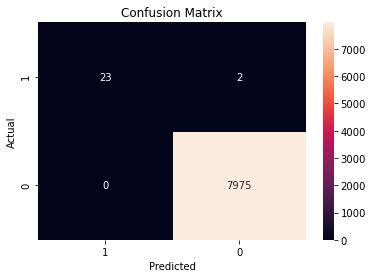

In [37]:
conf_matrix = confusion_matrix(true, preds)
ax = sns.heatmap(conf_matrix, annot=True,fmt='g')
ax.invert_xaxis()
ax.invert_yaxis()
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")

# Custom dataset test :

### Step 0: Setup and Imports

In [2]:
import pandas as pd
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
import numpy as np
import subprocess
import json
import requests
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


### Step 1: Create Custom Dataset

In [3]:
# Create a custom binary classification dataset (simulating fraud detection)
print("Creating custom dataset...")
X, y = make_classification(
    n_samples=10000,
    n_features=28,
    n_informative=20,
    n_redundant=5,
    n_classes=2,
    weights=[0.97, 0.03],  # Imbalanced dataset like fraud detection
    flip_y=0.02,
    random_state=42
)

# Create DataFrame
feature_names = [f'Feature_{i}' for i in range(1, 29)]
df = pd.DataFrame(X, columns=feature_names)
df['Time'] = np.arange(len(df))  # Add time column
df['Class'] = y  # Target variable (0: normal, 1: anomaly/fraud)

# Reorder columns
df = df[['Time'] + feature_names + ['Class']]

# Save dataset
df.to_csv('custom_fraud_data.csv', index=False)

print(f"✅ Dataset created with {len(df)} samples")
print(f"   Normal cases: {(df.Class == 0).sum()}")
print(f"   Anomaly cases: {(df.Class == 1).sum()}")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Creating custom dataset...
✅ Dataset created with 10000 samples
   Normal cases: 9608
   Anomaly cases: 392

Dataset shape: (10000, 30)

First 5 rows:


,Time,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Class
0,0,0.748945,0.616355,0.712701,2.681266,-3.715161,0.950169,-3.396104,0.756948,-0.185848,...,-0.920123,4.995390,0.832708,0.866538,-1.475779,-4.660361,5.496217,1.856814,-0.321572,0
1,1,0.935258,5.296715,-1.421601,-4.406296,-2.652466,-4.292803,5.524108,-0.917610,-12.852796,...,4.812054,3.822284,-0.170116,-0.442542,-0.105911,0.113330,-12.368706,0.481317,-1.499641,0
2,2,0.872043,1.694777,-2.650149,2.825650,-2.135304,3.325043,-2.212077,1.185695,-3.638635,...,0.976569,4.616873,-2.654489,0.805494,-1.054507,-0.261772,8.294462,3.711510,-1.124947,0
3,3,-0.663192,0.849317,0.164833,0.971602,-0.373165,1.381983,1.280861,-0.108531,4.428081,...,1.490138,10.026260,-5.287238,-1.336376,0.184000,5.971898,12.352797,-9.178702,0.727777,0
4,4,0.401002,-0.048611,-3.776054,3.248844,0.770785,4.539528,0.737590,-0.605734,-2.290221,...,-4.594788,7.388546,-1.284368,-1.048443,-0.387376,-6.057142,1.373334,1.364143,-0.483966,0


In [4]:
# Dataset info
print("Dataset Information:")
print(df.info())
print("\nClass distribution:")
print(df['Class'].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time        10000 non-null  int32  
 1   Feature_1   10000 non-null  float64
 2   Feature_2   10000 non-null  float64
 3   Feature_3   10000 non-null  float64
 4   Feature_4   10000 non-null  float64
 5   Feature_5   10000 non-null  float64
 6   Feature_6   10000 non-null  float64
 7   Feature_7   10000 non-null  float64
 8   Feature_8   10000 non-null  float64
 9   Feature_9   10000 non-null  float64
 10  Feature_10  10000 non-null  float64
 11  Feature_11  10000 non-null  float64
 12  Feature_12  10000 non-null  float64
 13  Feature_13  10000 non-null  float64
 14  Feature_14  10000 non-null  float64
 15  Feature_15  10000 non-null  float64
 16  Feature_16  10000 non-null  float64
 17  Feature_17  10000 non-null  float64
 18  Feature_18  10000 non-null  float64
 19  Featu

### Step 2: Train and Log Model with MLflow

In [5]:
# Prepare data
print("Preparing data for training...")

# Separate normal and anomaly samples
normal = df[df.Class == 0].sample(frac=0.5, random_state=2020).reset_index(drop=True)
anomaly = df[df.Class == 1]

# Split data
normal_train, normal_test = train_test_split(normal, test_size=0.2, random_state=2020)
anomaly_train, anomaly_test = train_test_split(anomaly, test_size=0.2, random_state=2020)

# Combine train and test sets
train_df = pd.concat((normal_train, anomaly_train)).reset_index(drop=True)
test_df = pd.concat((normal_test, anomaly_test)).reset_index(drop=True)

# Prepare features
X_train = train_df.drop(["Time", "Class"], axis=1)
y_train = train_df.Class
X_test = test_df.drop(["Time", "Class"], axis=1)
y_test = test_df.Class

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data prepared:")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")

Preparing data for training...
✅ Data prepared:
   Training samples: 4156
   Test samples: 1040


In [6]:
# Set MLflow experiment
mlflow.set_experiment("custom_fraud_detection_experiment")

print("Training model with MLflow...")

# Start MLflow run
with mlflow.start_run(run_name="logistic_regression_model") as run:
    # Train model
    model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_scaled)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    
    # Log parameters
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("n_features", X_train.shape[1])
    
    # Log metrics
    mlflow.log_metric("train_accuracy", train_acc)
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("test_auc", test_auc)
    
    # Log model
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="log_reg_model",
        registered_model_name="fraud_detection_lr"
    )
    
    run_id = run.info.run_id
    
    print(f"\n✅ Model training complete!")
    print(f"   Run ID: {run_id}")
    print(f"   Train Accuracy: {train_acc:.4f}")
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Train AUC: {train_auc:.4f}")
    print(f"   Test AUC: {test_auc:.4f}")
    print(f"\n📝 Save this Run ID for model serving: {run_id}")

2025/11/16 21:37:46 INFO mlflow.tracking.fluent: Experiment with name 'custom_fraud_detection_experiment' does not exist. Creating a new experiment.


Training model with MLflow...


2025/11/16 21:37:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 21:37:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ Model training complete!
   Run ID: 6e3daba3bd164896aac6477900deaed8
   Train Accuracy: 0.7372
   Test Accuracy: 0.7144
   Train AUC: 0.7971
   Test AUC: 0.7982

📝 Save this Run ID for model serving: 6e3daba3bd164896aac6477900deaed8


Successfully registered model 'fraud_detection_lr'.
Created version '1' of model 'fraud_detection_lr'.


In [ ]:
# run 
# mlflow models serve --model-uri runs:/6e3daba3bd164896aac6477900deaed8/log_reg_model -p 1235

### Step 4: Query the Model - Using (requests library)

In [8]:
# Load data for inference
df = pd.read_csv("custom_fraud_data.csv")
print(f"Data loaded: {df.shape}")

Data loaded: (10000, 30)


In [18]:
print("Querying model using requests library...")

# Setup request
host = '127.0.0.1'
port = '1236'
url = f'http://{host}:{port}/invocations'
headers = {'Content-Type': 'application/json'}

# Send request
r = requests.post(url=url, headers=headers, data=input_json)

if r.status_code == 200:
    predictions_requests = json.loads(r.text)['predictions']
    print(f"\n✅ Successfully received predictions")
    print(f"   Status Code: {r.status_code}")
    print(f"   Number of predictions: {len(predictions_requests)}")
    print(f"\nPredictions (first 20): {predictions_requests[:20]}")
else:
    print(f"❌ Error: Status Code {r.status_code}")
    print(f"Response: {r.text}")

Querying model using requests library...

✅ Successfully received predictions
   Status Code: 200
   Number of predictions: 80

Predictions (first 20): [0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1]


### Step 7: Batch Prediction and Evaluation

In [20]:
print("Performing batch prediction on 8000 samples...\n")

# Prepare data with scaling
normal = df[df.Class == 0].sample(frac=0.5, random_state=2020).reset_index(drop=True)
anomaly = df[df.Class == 1]
normal_train, normal_test = train_test_split(normal, test_size=0.2, random_state=2020)
anomaly_train, anomaly_test = train_test_split(anomaly, test_size=0.2, random_state=2020)

# Fit scaler
scaler = StandardScaler()
scaler.fit(pd.concat((normal, anomaly)).drop(["Time", "Class"], axis=1))

# Prepare test set
test = df.iloc[:8000]
true = test.Class.values
test_scaled = scaler.transform(test.drop(["Time", "Class"], axis=1))

# Batch prediction
preds = []
batch_size = 80
n_batches = 100  # 8000 / 80 = 100 batches

print(f"Processing {n_batches} batches of {batch_size} samples each...")

for i in range(n_batches):
    # Prepare batch
    batch_df = pd.DataFrame(test_scaled[i*batch_size:(i+1)*batch_size])
    batch_dict = {
        "dataframe_split": {
            "columns": batch_df.columns.tolist(),
            "data": batch_df.values.tolist()
        }
    }
    
    # Send request using requests library
    try:
        r = requests.post(url=url, headers=headers, json=batch_dict, timeout=30)
        if r.status_code == 200:
            batch_preds = r.json()['predictions']
            preds.extend(batch_preds)
        
        # Progress indicator
        if (i + 1) % 20 == 0:
            print(f"  Processed {i + 1}/{n_batches} batches...")
    
    except Exception as e:
        print(f"❌ Error in batch {i}: {e}")
        break

Performing batch prediction on 8000 samples...

Processing 100 batches of 80 samples each...
  Processed 20/100 batches...
  Processed 40/100 batches...
  Processed 60/100 batches...
  Processed 80/100 batches...
  Processed 100/100 batches...


### Step 8: Model Evaluation

In [21]:
# Calculate metrics
eval_acc = accuracy_score(true, preds)
eval_auc = roc_auc_score(true, preds)

print("="*80)
print("EVALUATION RESULTS")
print("="*80)
print(f"Evaluation Accuracy: {eval_acc:.6f} ({eval_acc*100:.2f}%)")
print(f"Evaluation AUC:      {eval_auc:.6f}")
print("="*80)

# Detailed classification report
print("\nDetailed Classification Report:")
print("="*80)
print(classification_report(true, preds, target_names=['Normal', 'Fraud']))
print("="*80)

EVALUATION RESULTS
Evaluation Accuracy: 0.725000 (72.50%)
Evaluation AUC:      0.720953

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.73      0.84      7686
       Fraud       0.10      0.72      0.17       314

    accuracy                           0.72      8000
   macro avg       0.54      0.72      0.50      8000
weighted avg       0.95      0.72      0.81      8000



### Step 9: Confusion Matrix Visualization

✅ Confusion matrix saved as 'confusion_matrix.png'


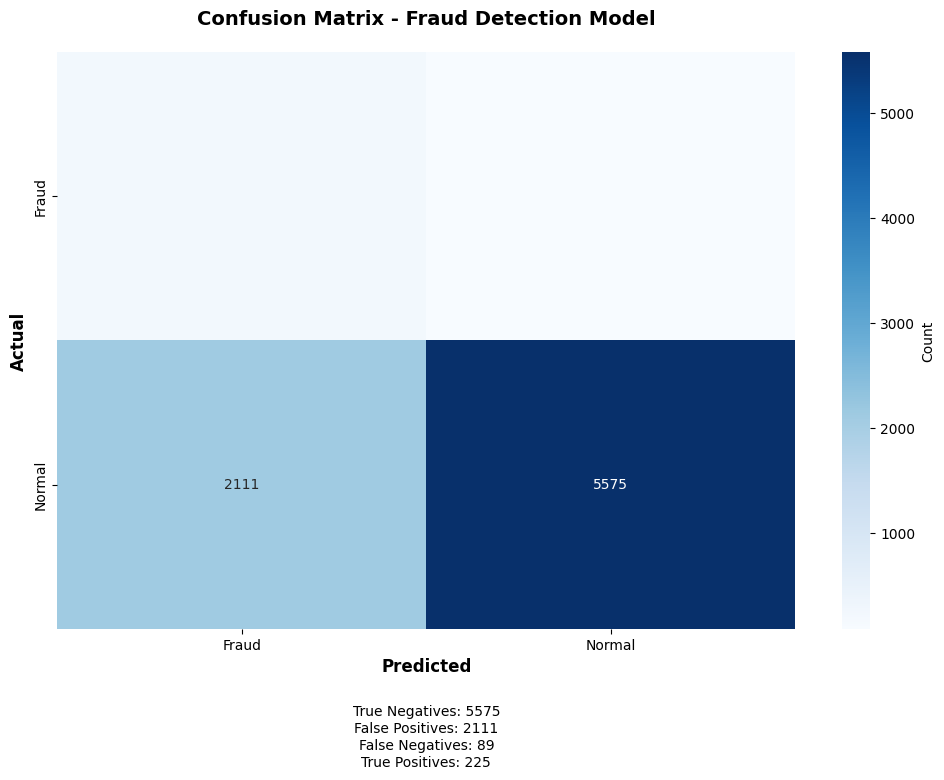

In [22]:
# Create confusion matrix
conf_matrix = confusion_matrix(true, preds)

# Plot
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='g', 
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud'],
    cbar_kws={'label': 'Count'}
)
ax.invert_yaxis()
ax.invert_xaxis()

plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Fraud Detection Model', fontsize=14, fontweight='bold', pad=20)

# Add value annotations
tn, fp, fn, tp = conf_matrix.ravel()
plt.text(0.5, -0.15, f'True Negatives: {tn}', transform=ax.transAxes, ha='center')
plt.text(0.5, -0.18, f'False Positives: {fp}', transform=ax.transAxes, ha='center')
plt.text(0.5, -0.21, f'False Negatives: {fn}', transform=ax.transAxes, ha='center')
plt.text(0.5, -0.24, f'True Positives: {tp}', transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Confusion matrix saved as 'confusion_matrix.png'")
plt.show()